Importing libraries

In [1]:
# Basic library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For loading dataset
from sklearn.datasets import load_iris

# For preprocessing, model implementation and evaluation
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, precision_recall_curve, auc

# Loading the dataset

In [2]:
data = load_iris()
X = data.data
y = data.target
print(X.shape)

(150, 4)


In [3]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [4]:
# Converting to dataframe
df = pd.DataFrame(X,columns=data.feature_names)
df['Target'] = y
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Target  
0       0  
1       0  
2       0  
3       0  
4       0  


# Class distribution of dataset

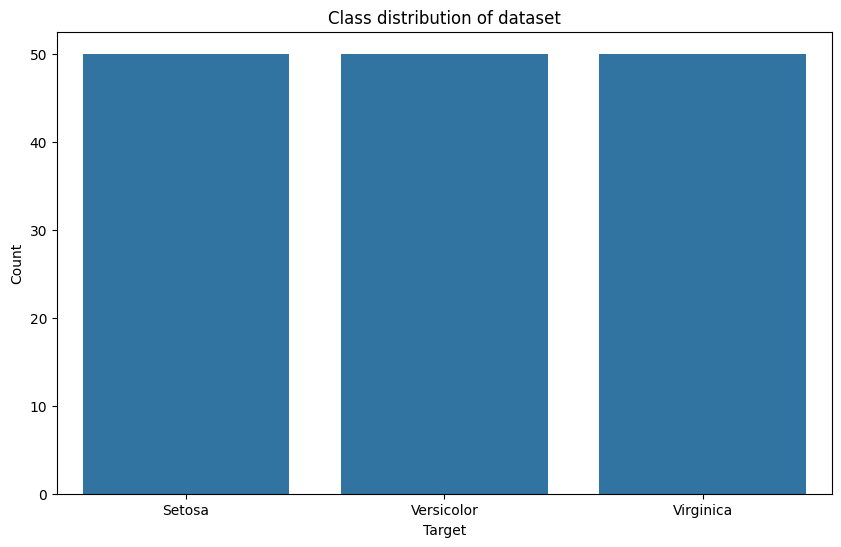

In [5]:
plt.figure(figsize = (10,6))
sns.barplot(x=df['Target'].value_counts().index,y=df['Target'].value_counts().values)
plt.title('Class distribution of dataset')
plt.xticks(np.arange(3),('Setosa','Versicolor','Virginica'))
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

From the above bar graph, we can conclude that the dataset is balanced containing 50 samples from each class.

# Encoding as one hot vectors

In [6]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[['Target']])
one_hot_df = pd.DataFrame(one_hot_encoded,columns=encoder.get_feature_names_out())
df = pd.concat([df,one_hot_df],axis=1)
df.drop('Target',axis=1,inplace=True)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Target_0  Target_1  Target_2  
0       1.0       0.0       0.0  
1       1.0       0.0       0.0  
2       1.0       0.0       0.0  
3       1.0       0.0       0.0  
4       1.0       0.0       0.0  


# Splitting the data into training, validation and test sets

In [7]:
X = df.iloc[:,:4]
y = df.iloc[:,4:]
print(X)
print(y)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]
     Target_0  Target_1  Target_2
0     

In [8]:
X_train,X_temp,y_train,y_temp = train_test_split(X,y,test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [9]:
print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 105
Validation set size: 22
Test set size: 23


# Standardization

In [10]:
scaler = StandardScaler()

In [11]:
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Softmax Regression Implementation from Scratch

In [12]:
class SoftmaxScratch:
  def __init__(self, n_features, n_classes, learning_rate=0.01, epochs=1000, reg_strength=0.01):
    self.lr = learning_rate
    self.epochs = epochs
    self.reg_strength = reg_strength

    # Initialize weights and bias
    self.weights = np.zeros((n_features, n_classes))
    self.b = np.zeros((1,n_classes))

    self.training_loss = []
    self.val_loss = []

  def softmax(self, z):
    y_hat = np.exp(z) / np.sum(np.exp(z), axis=1, keepdims=True)
    return y_hat

  def compute_loss(self,y,y_pred):
    epsilon = 1e-15

    # Cross entropy loss for all samples
    n = y.shape[0]
    ce_loss = -np.sum(y * np.log(y_pred + epsilon)) / n

    # L2 regularization term
    reg_term = (self.reg_strength / 2) * np.sum(self.weights ** 2)

    # Total loss
    total_loss = ce_loss + reg_term
    return total_loss

  def predict_prob(self, X):
    z = np.dot(X, self.weights) + self.b
    return self.softmax(z)

  def predict(self, X):
    probs = self.predict_prob(X)
    return np.argmax(probs, axis=1)

  def fit(self, X_train, y_train, X_val, y_val):
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    X_val = np.array(X_val)
    y_val = np.array(y_val)
    n, n_features = X_train.shape

    for epoch in range(self.epochs):
      y_pred = self.predict_prob(X_train)

      # Compute training loss
      t_loss = self.compute_loss(y_train, y_pred)
      self.training_loss.append(t_loss)

      # Validation loss
      y_val_pred = self.predict_prob(X_val)
      v_loss = self.compute_loss(y_val, y_val_pred)
      self.val_loss.append(v_loss)

      # Compute gradients
      dw = (1 / n) * np.dot(X_train.T, (y_pred - y_train)) + self.reg_strength * self.weights
      db = (1 / n) * np.sum(y_pred - y_train, axis=0, keepdims=True)

      # Update weights and bias
      self.weights -= self.lr * dw
      self.b -= self.lr * db


In [13]:
def hyperparameters(X_train, y_train, X_val, y_val, learning_rates, reg_strengths, epochs=1000):
  best_val_loss = float('inf')
  best_params = None
  for lr in learning_rates:
    for reg in reg_strengths:
      model = SoftmaxScratch(n_features=X_train.shape[1], n_classes=y_train.shape[1], learning_rate=lr, epochs=epochs, reg_strength=reg)
      model.fit(X_train, y_train, X_val, y_val)

      validation_loss = model.val_loss[-1]

      if validation_loss < best_val_loss:
        best_val_loss = validation_loss
        best_params = (lr, reg)

      plt.figure(figsize=(8,6))
      plt.plot(model.training_loss, label='Training Loss')
      plt.plot(model.val_loss, label='Validation Loss')
      plt.title(f'Learning Rate: {lr:.2f}, Regularization Strength: {reg:.2f}')
      plt.xlabel('Epochs')
      plt.ylabel('Loss')
      plt.legend()
      plt.show()


  return best_params

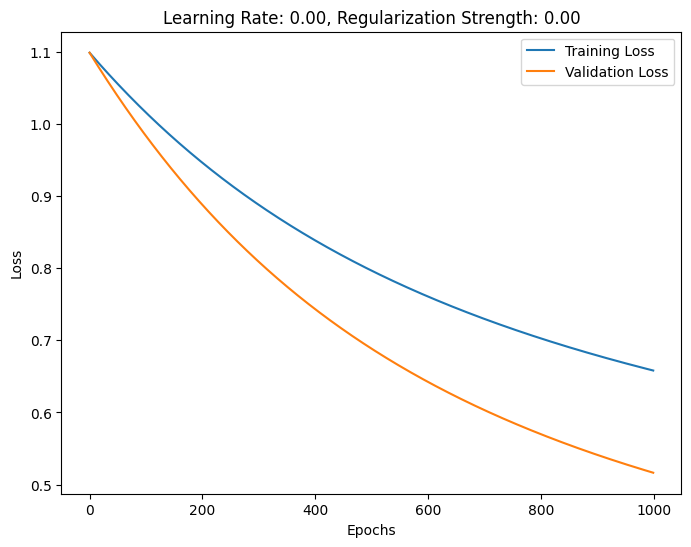

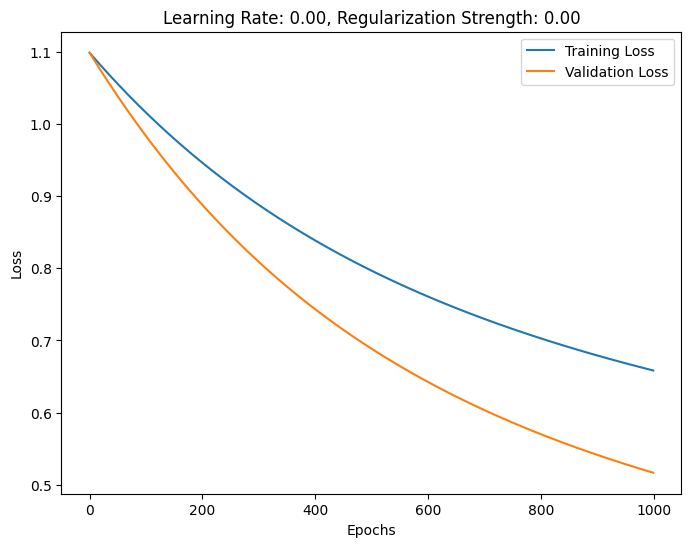

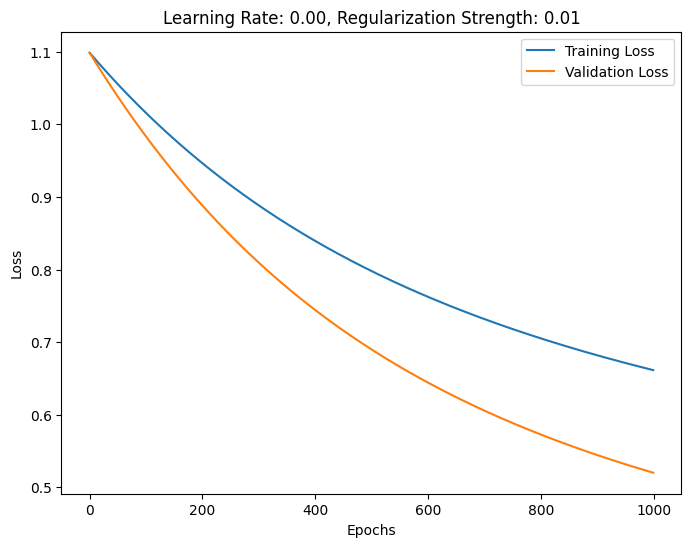

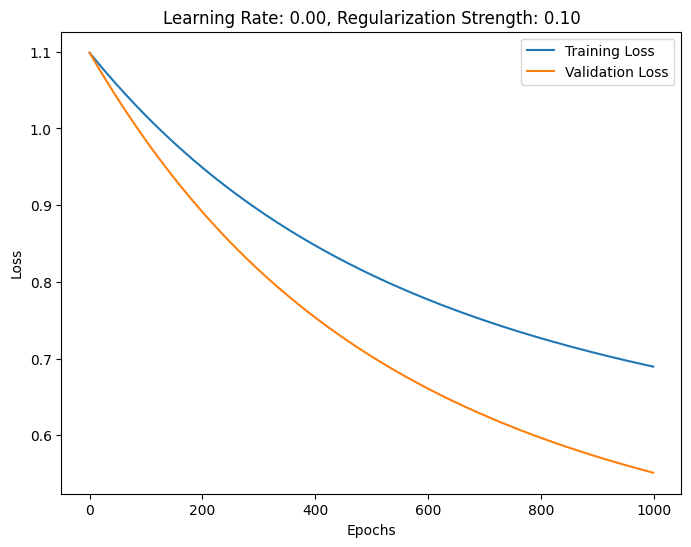

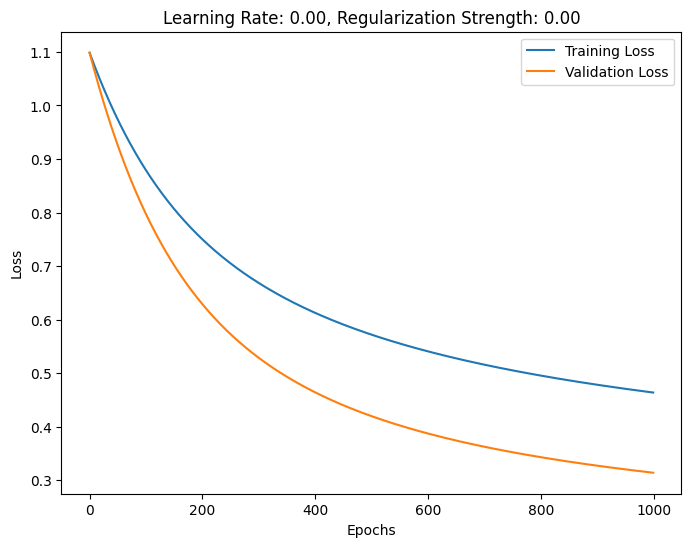

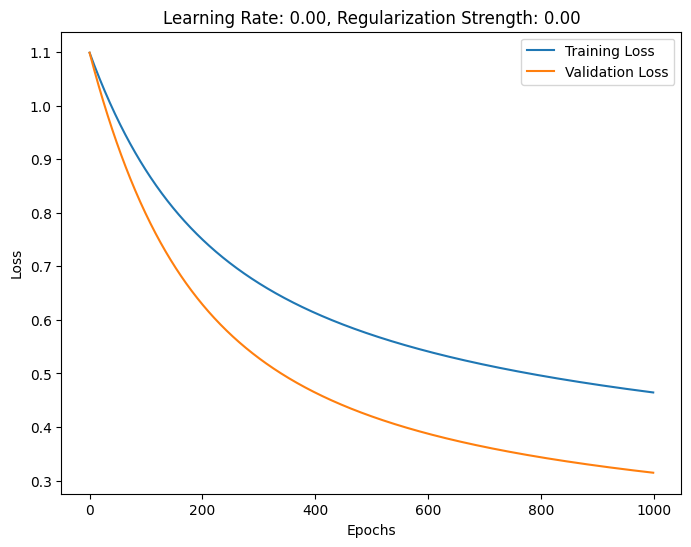

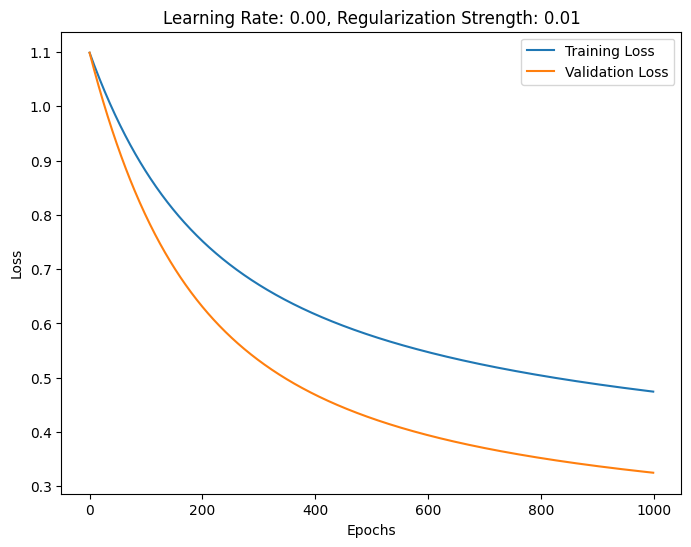

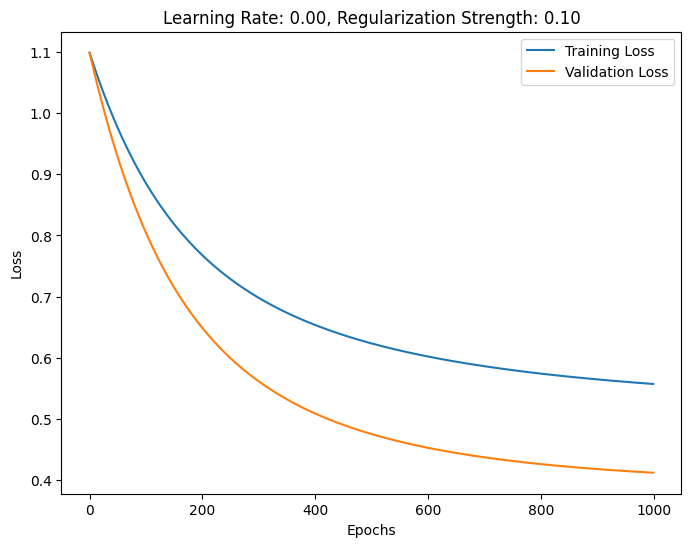

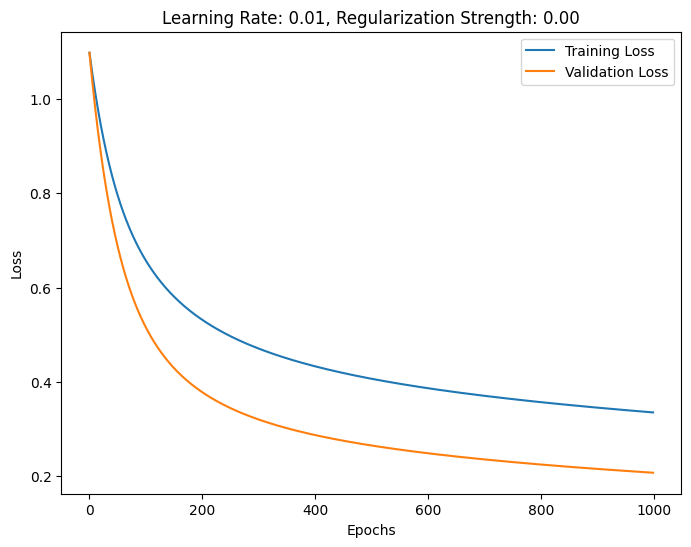

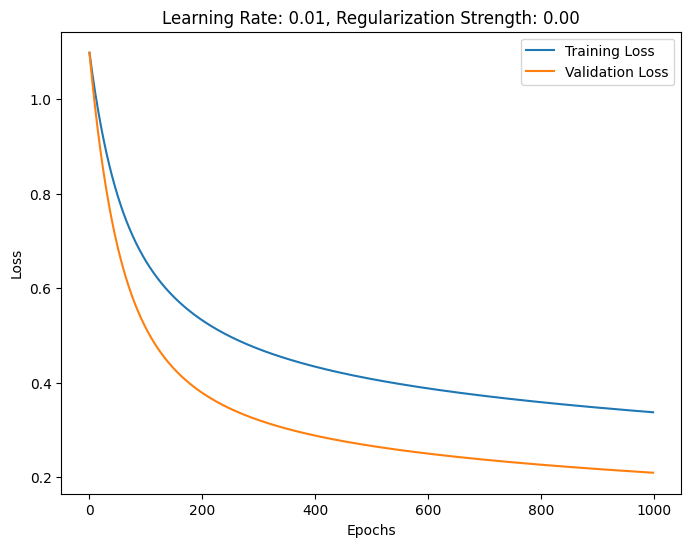

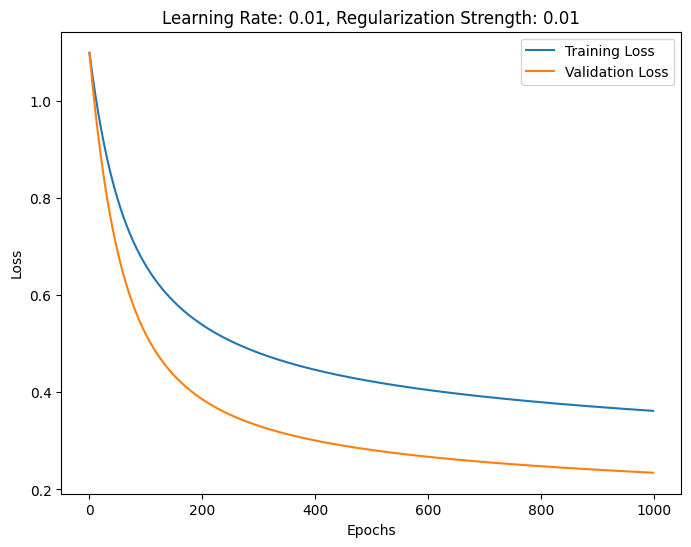

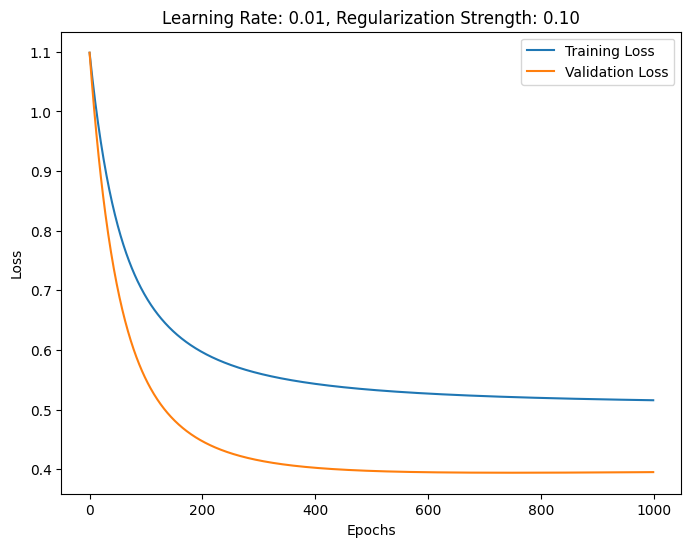

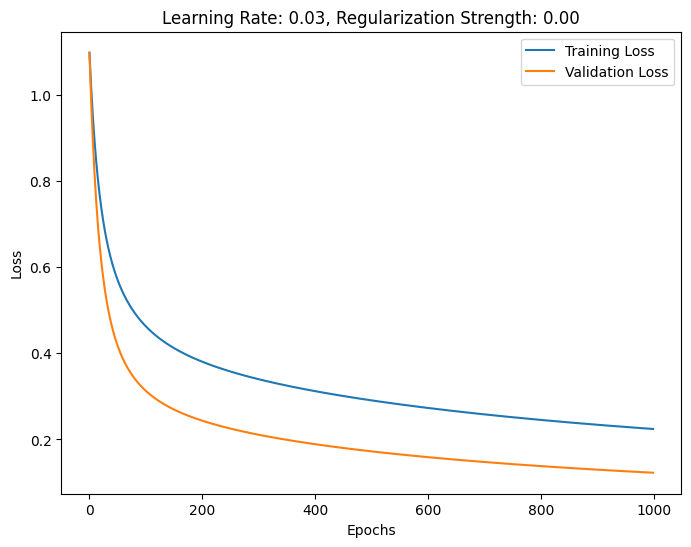

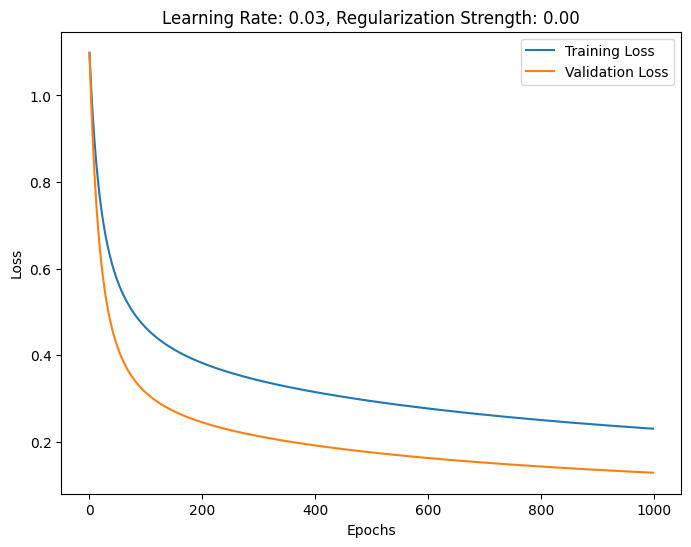

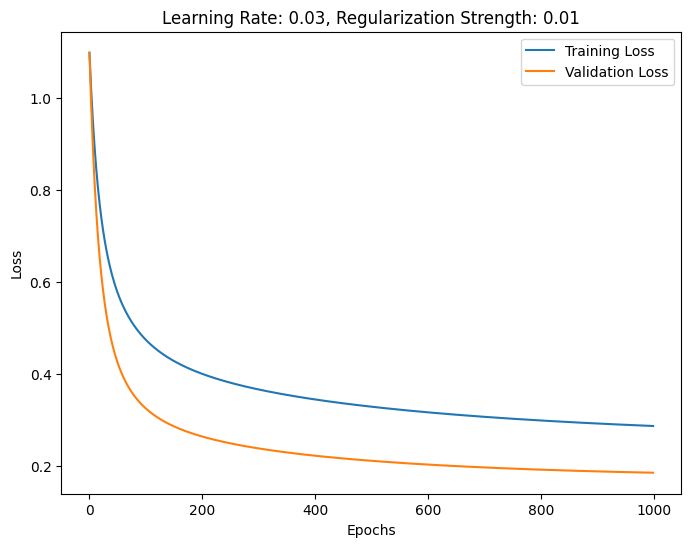

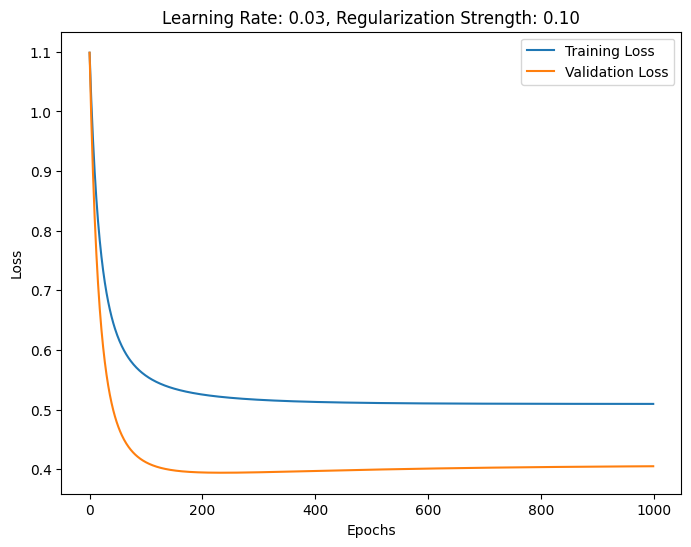

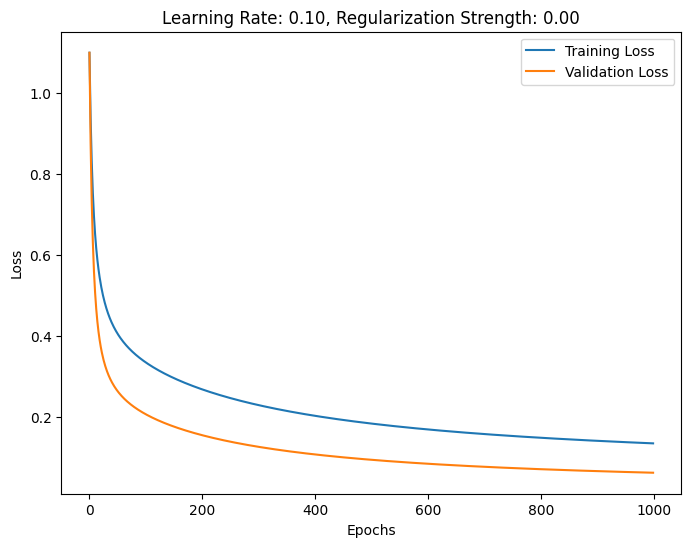

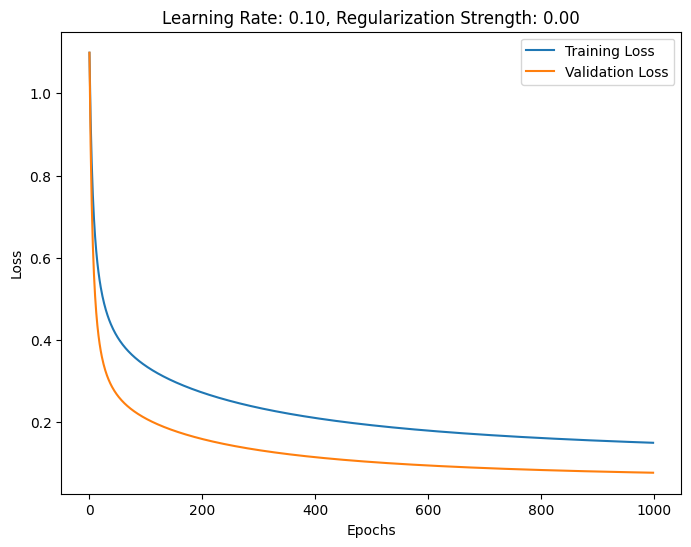

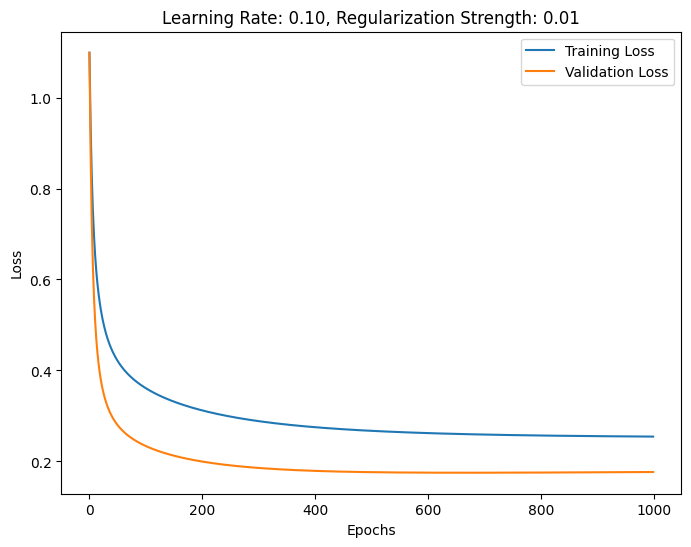

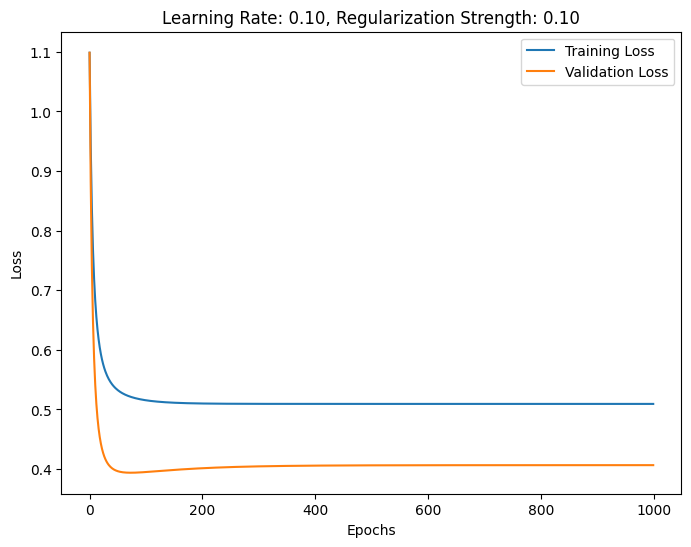

(np.float64(0.1), np.float64(0.0001))


In [14]:
lrates = np.logspace(-3,-1,5)
strengths = np.logspace(-4,-1,4)

best_params = hyperparameters(X_train, y_train, X_val, y_val, learning_rates=lrates, reg_strengths=strengths)
print(best_params)

Best lr = 0.1<br>
Best reg_strength = 0.0001

# Prediction performance

In [15]:
best_model = SoftmaxScratch(n_features=X_train.shape[1], n_classes=y_train.shape[1], learning_rate=best_params[0], epochs=1000, reg_strength=best_params[1])
best_model.fit(X_train, y_train, X_val, y_val)

In [16]:
y_test = np.array(y_test)

y_test_pred = best_model.predict(X_test)
y_test_true = np.argmax(y_test, axis=1)

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test_true, y_test_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 6  0  0]
 [ 0 10  0]
 [ 0  0  7]]


In [18]:
# Precision and Recall
prec = precision_score(y_test_true, y_test_pred, average='macro')
rec = recall_score(y_test_true, y_test_pred, average='macro')
print("Precision:", prec)
print("Recall:", rec)

Precision: 1.0
Recall: 1.0


In [19]:
# Area under Precision-Recall Curve
auprc = 0
y_test_pred_probs = best_model.predict_prob(X_test)
for i in range(y_test.shape[1]):
  precision, recall, _ = precision_recall_curve(y_test[:, i], y_test_pred_probs[:, i])
  auprc += auc(recall, precision)
auprc /= y_test.shape[1]
print("Area under Precision-Recall Curve:", auprc)

Area under Precision-Recall Curve: 1.0


# Comparison with sklearn Softmax implementation

In [20]:
# Converting the one hot labels back to original
y_train_labels = np.argmax(y_train, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# C = inverse of regularization strength
C = 1/best_params[1]

# Train sklearn model
clf = LogisticRegression(multi_class='multinomial', solver='lbfgs', C=C, max_iter=1000, penalty='l2')
clf.fit(X_train, y_train_labels)

y_pred_sklearn = clf.predict(X_test)
y_test_pred_probs_sklearn = clf.predict_proba(X_test)


c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [21]:
prec_sklearn = precision_score(y_test_labels, y_pred_sklearn, average='macro')
rec_sklearn = recall_score(y_test_labels, y_pred_sklearn, average='macro')

In [22]:
print(prec_sklearn)
print(rec_sklearn)

1.0
1.0


In [23]:
# AUPRC for sklearn
auprc_sklearn = 0
for i in range(y_train.shape[1]):
    precision, recall, _ = precision_recall_curve(y_test[:, i], y_test_pred_probs_sklearn[:, i])
    auprc_sklearn += auc(recall, precision)
auprc_sklearn /= y_train.shape[1]

In [24]:
print(auprc_sklearn)

1.0
